In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing as mp
from scipy.interpolate import interp1d
from matplotlib.ticker import AutoMinorLocator
from NSC_cosmo import background, PertEMD_noAX
from NSC_axions import NSC_PERT_axi
from QCD_axions import NSC_PERT_axi as QCD_PERT_axi
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.optimize import root_scalar
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "pdf.fonttype": 42,  
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    
    "font.family": "serif",
    "font.size": 16,
    
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


labR = r'$R/R_I$'
labx  = r'$x$'
labka = r'$\kappa$'
labrh= r'$\rho_i$~[GeV$^4$]'
labT = r'$T$~[GeV]'
labdr= r'$|\delta_r(\kappa,x)|$'
labdp= r'$|\delta_\phi(\kappa,x)|$'
labtr= r'$|\theta_r(\kappa,x)|/k_\text{RH}$'
labtp= r'$|\theta_\phi(\kappa,x)|/k_\text{RH}$'
labPh= r'$|\Phi(\kappa,x)|$'

labdr2= labdr
labdp2= labdp
labtr2= labtr
labtp2= labtp
labPh2= labPh

labma= r'$m_a$~[GeV]'
labth= r'$\theta_0$'
Phi_p = np.sqrt(2.101* 10**(-9))  



In [2]:

Tend = 0.015
Tini = 3e1
kappa = 1e5
maxi = 200

R, rho_phi, rho_r, Temp, Hub, GG, R_RH,k_RH = background(Tend, Tini, maxi, kappa)
H_RH = Hub[np.argmin(np.abs(R_RH - R))]

Saved successfully: Plots/NSC_background/Background_NSC.pdf


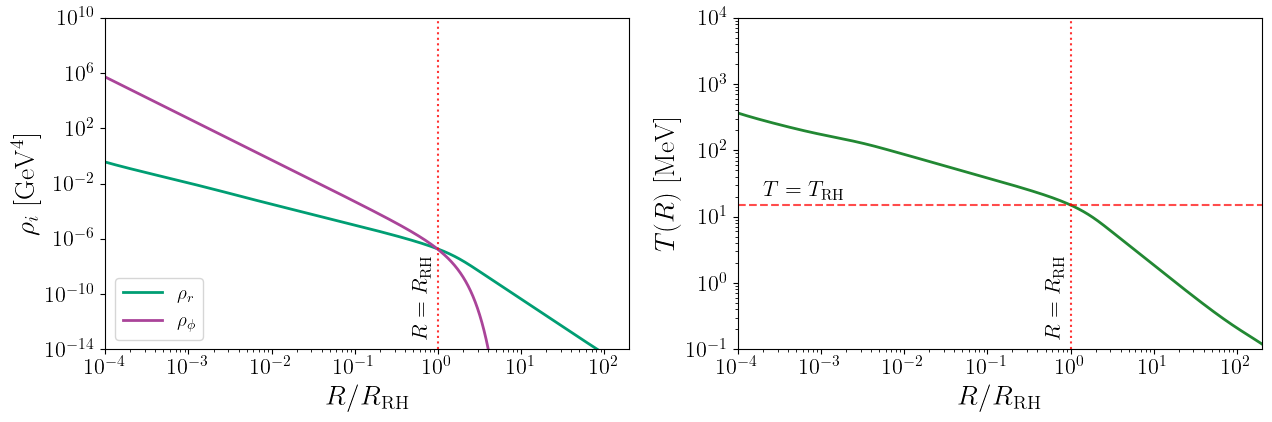

In [3]:
x = R / R_RH
x_min, x_max = 1e-4, R[-1] / R_RH
color_r = "#009E73"
color_phi = "#AA4499"
color_T = "#228833"
output_dir = "Plots/NSC_background"
__import__("pathlib").Path(output_dir).mkdir(parents=True, exist_ok=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(x, rho_r, color=color_r, lw=2, label=r"$\rho_r$")
ax1.plot(x, rho_phi, color=color_phi, lw=2, label=r"$\rho_\phi$")
ax1.axvline(1.0, color="red", linestyle=":", alpha=0.8)
ax1.text(0.85, 5e-14, r"$R=R_{\mathrm{RH}}$", rotation=90, va="bottom", ha="right", color="black")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(bottom=1e-14, top=1e10)
ax1.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax1.set_ylabel(r"$\rho_i~[\mathrm{GeV}^4]$")
legend1 = ax1.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.8)
legend1.get_frame().set_linewidth(1.0)
ax2.plot(x, Temp * 1e3, color=color_T, lw=2)
T_end_MeV = Tend * 1e3
ax2.axhline(T_end_MeV, color="red", linestyle="--", alpha=0.7)
ax2.text(2e-4, T_end_MeV * 1.15, r"$T=T_{\mathrm{RH}}$", color="black", va="bottom", ha="left")
ax2.axvline(1.0, color="red", linestyle=":", alpha=0.8)
ax2.text(0.85, 0.14, r"$R=R_{\mathrm{RH}}$", rotation=90, va="bottom", ha="right", color="black")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(bottom=1e-1, top=1e4)
ax2.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax2.set_ylabel(r"$T(R)~[\mathrm{MeV}]$")
fig.tight_layout()
output_path = f"{output_dir}/Background_NSC.pdf"
fig.savefig(output_path, bbox_inches="tight", dpi=300)
print(f"Saved successfully: {output_path}")
plt.show()

In [4]:
def worker_pert(k):
    return PertEMD_noAX(rho_phi, rho_r, GG, R, k)

kappas_log = np.logspace(np.log10(0.1), np.log10(250), 450)
kappas_special = np.array([100.0, 50.0, 10.0, 1.0, 0.1])
kappas = np.unique(np.concatenate([kappas_log, kappas_special]))
k_vals = k_RH * kappas
n_workers = max(1, min(len(k_vals), int(mp.cpu_count() * 0.85)))

print(f"Calculating {len(k_vals)} modes using {n_workers} cores...")

pert_results = list(tqdm(
    Parallel(n_jobs=n_workers, return_as="generator")(
        delayed(worker_pert)(k) for k in k_vals
    ),
    total=len(k_vals),
    desc="Calculating k modes"
))

delta_r_k, delta_phi_k, Phi_k, theta_phi_k, theta_r_k, dPhi_dR_k = map(list, zip(*pert_results))

print("Calculations finished!")

Calculating 454 modes using 47 cores...


Calculating k modes: 100%|██████████| 454/454 [01:29<00:00,  5.05it/s]

Calculations finished!


Successfully saved: Plots/NSC_pert/NSC_delta_phi.pdf


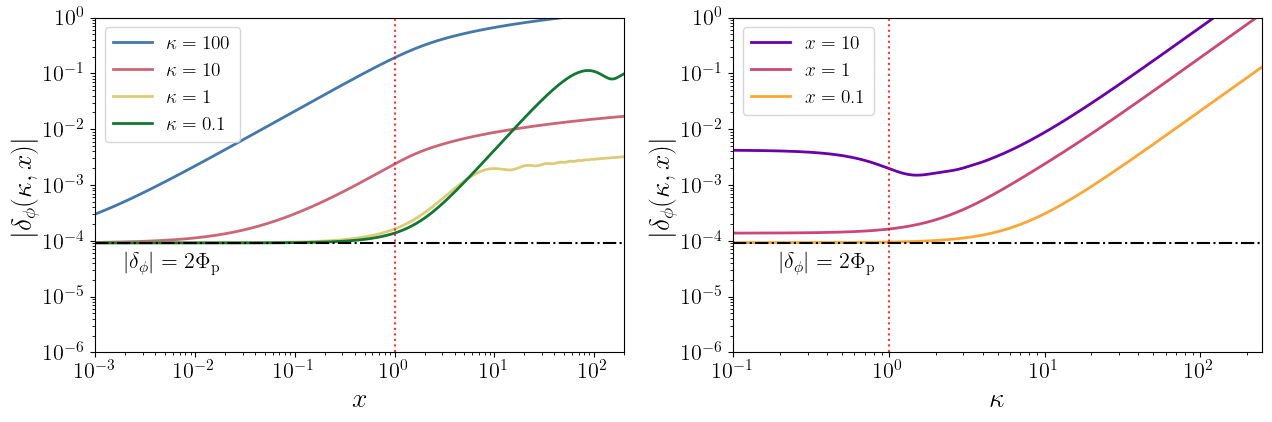

Successfully saved: Plots/NSC_pert/NSC_delta_r.pdf


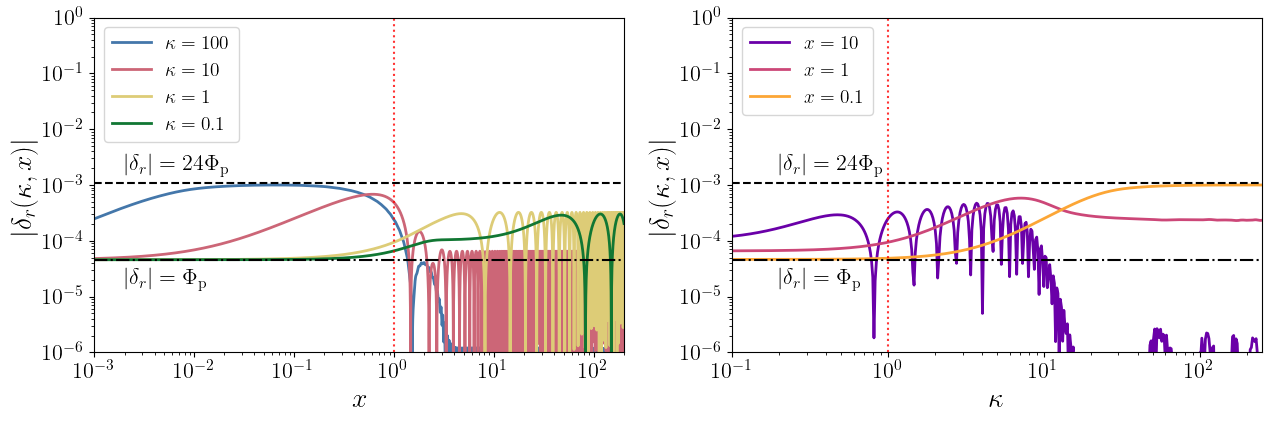

Successfully saved: Plots/NSC_pert/NSC_Phi.pdf


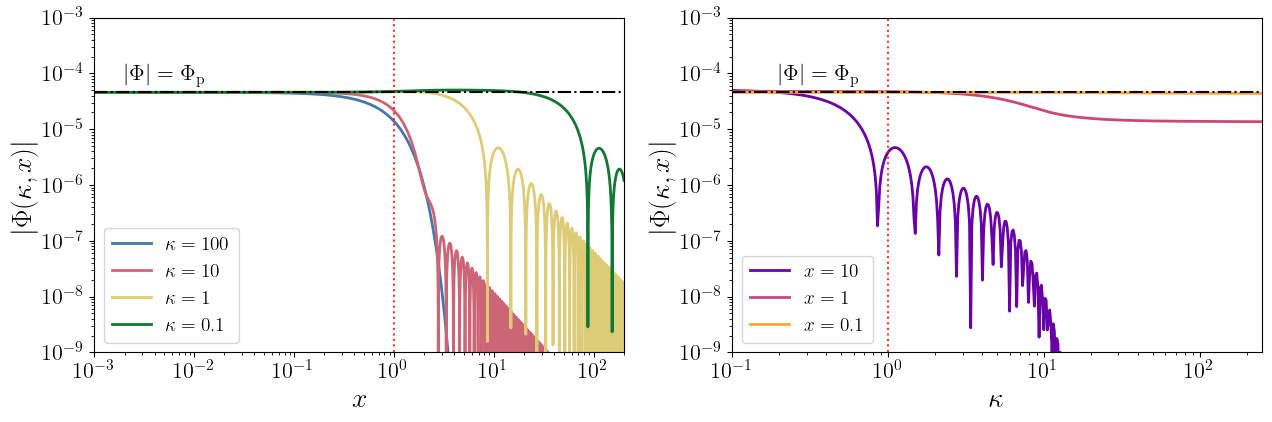

Successfully saved: Plots/NSC_pert/NSC_theta_phi.pdf


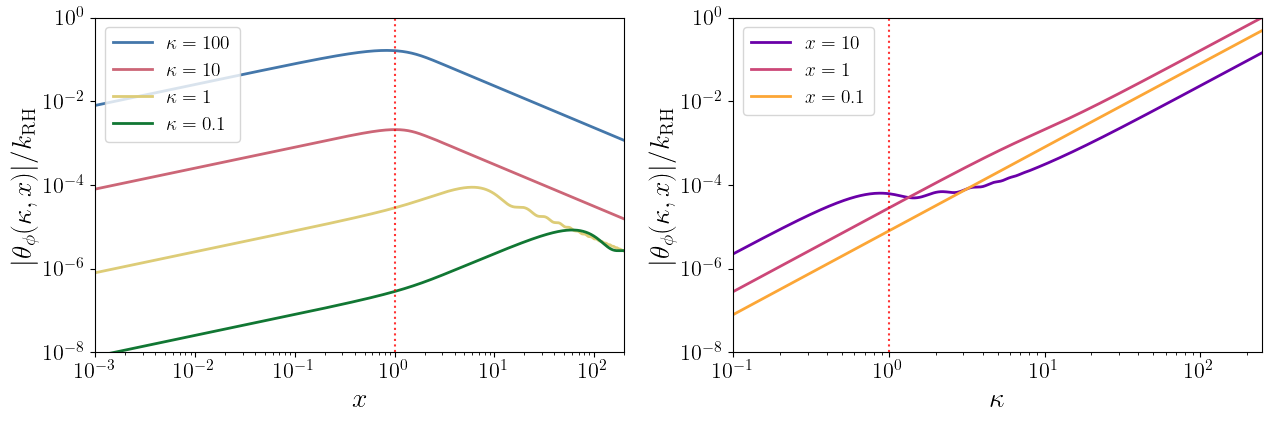

Successfully saved: Plots/NSC_pert/NSC_theta_r.pdf


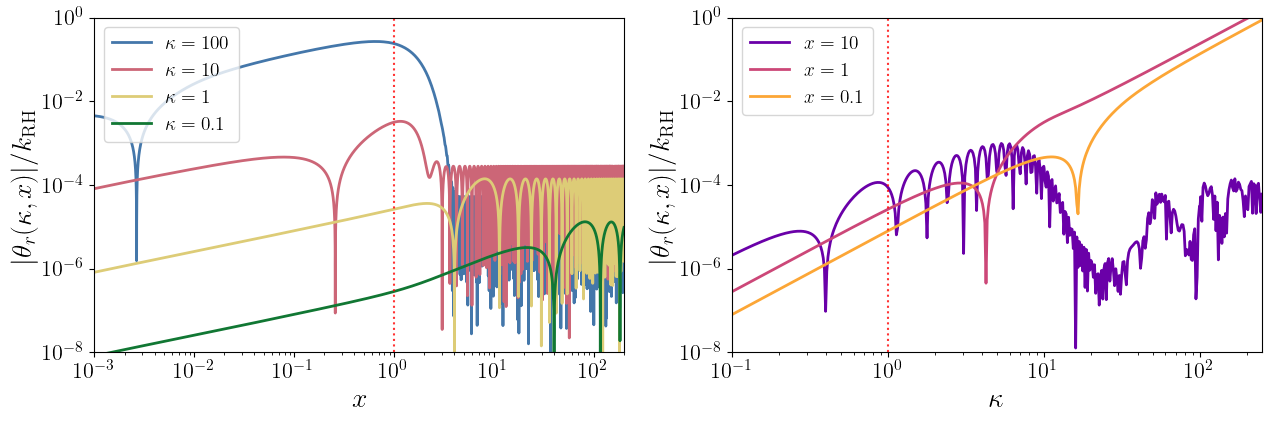

In [5]:
mat_delta_r = np.abs(np.array(delta_r_k))
mat_delta_phi = np.abs(np.array(delta_phi_k))
mat_Phi = np.abs(np.array(Phi_k))
mat_theta_phi = np.abs(np.array(theta_phi_k)) / k_RH
mat_theta_r = np.abs(np.array(theta_r_k)) / k_RH

perturbations = [
    (mat_delta_phi, labdp, "delta_phi", (1e-6, 1e0), [
        (2 * Phi_p, "black", "-.", r"$|\delta_{\phi}| = 2\Phi_{\mathrm{p}}$", "top")
    ]),
    (mat_delta_r, labdr, "delta_r", (1e-6, 1e0), [
        (24 * Phi_p, "black", "--", r"$|\delta_r| = 24\Phi_{\mathrm{p}}$", "bottom"),
        (Phi_p, "black", "-.", r"$|\delta_{r}| = \Phi_{\mathrm{p}}$", "top")
    ]),
    (mat_Phi, labPh, "Phi", (1e-9, 1e-3), [
        (Phi_p, "black", "-.", r"$|\Phi| = \Phi_{\mathrm{p}}$", "bottom")
    ]),
    (mat_theta_phi, labtp, "theta_phi", (1e-8, 1e0), []),
    (mat_theta_r, labtr, "theta_r", (1e-8, 1e0), [])
]

target_kappas = [100.0, 10.0, 1.0, 0.1]
idx_kappas = [np.where(np.isclose(kappas, k_val))[0][0] for k_val in target_kappas]

target_xs = [10.0, 1.0, 0.1]
idx_xs = [np.argmin(np.abs(x - x_val)) for x_val in target_xs]

mode_colors = ["#4477AA", "#CC6677", "#DDCC77", "#117733"]
slice_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(target_xs)))

output_dir = "Plots/NSC_pert"
__import__("pathlib").Path(output_dir).mkdir(parents=True, exist_ok=True)

for abs_matrix, ylabel, file_name, ylims, h_lines in perturbations:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 4.5))
    ax_left = axes[0]
    ax_right = axes[1]

    for k_val, idx_k, color in zip(target_kappas, idx_kappas, mode_colors):
        ax_left.loglog(x, abs_matrix[idx_k, :], color=color, lw=2, label=fr"$\kappa = {k_val:g}$")

    for x_val, idx_x, color in zip(target_xs, idx_xs, slice_colors):
        ax_right.loglog(kappas, abs_matrix[:, idx_x], color=color, lw=2, label=fr"$x = {x_val:g}$")

    ax_left.axvline(1.0, color="red", linestyle=":", alpha=0.8)
    ax_right.axvline(1.0, color="red", linestyle=":", alpha=0.8)

    ax_left.set_ylabel(ylabel)
    ax_left.set_xlabel(labx)
    ax_left.set_xlim(1e-3, maxi)
    ax_left.set_ylim(ylims)

    ax_right.set_ylabel(ylabel)
    ax_right.set_xlabel(labka)
    ax_right.set_xlim(kappas[0], kappas[-1])
    ax_right.set_ylim(ylims)

    for y_val, color, linestyle, text, va in h_lines:
        ax_left.axhline(y_val, color=color, linestyle=linestyle)
        ax_right.axhline(y_val, color=color, linestyle=linestyle)

        y_offset = y_val * 1.25 if va == "bottom" else y_val * 0.7

        ax_left.text(2e-3, y_offset, text, color=color, va=va)
        ax_right.text(2e-1, y_offset, text, color=color, va=va)

    legend_loc = "lower left" if file_name == "Phi" else "upper left"
    ax_left.legend(loc=legend_loc)
    ax_right.legend(loc=legend_loc)

    fig.tight_layout()

    pdf_name = f"{output_dir}/NSC_{file_name}.pdf"
    fig.savefig(pdf_name, bbox_inches="tight", dpi=300)
    print(f"Successfully saved: {pdf_name}")

    plt.show()
    plt.close(fig)

Saved successfully: Plots/NSC_background/Axion_background.pdf


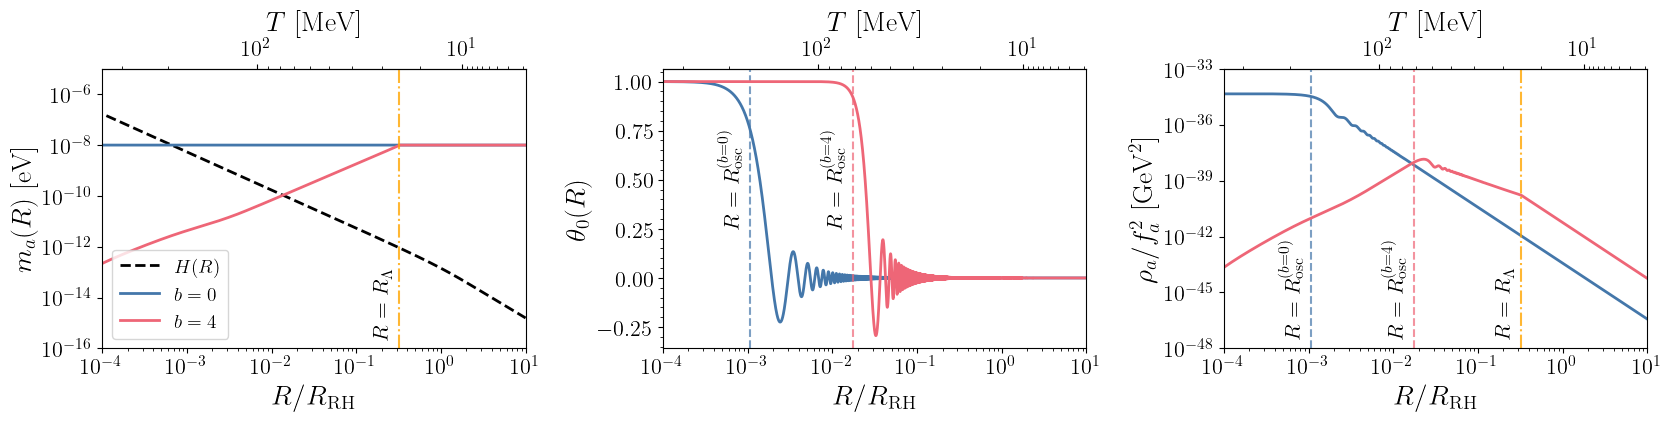

In [7]:
max_ax = 10.0
time_mask = R <= max_ax * R_RH

R_ax = R[time_mask]
rho_phi_ax = rho_phi[time_mask]
rho_r_ax = rho_r[time_mask]
Temp_ax = Temp[time_mask]
Hub_ax = Hub[time_mask]
GG_ax = GG[time_mask]
x_ax = R_ax / R_RH

delta_r_k_ax = np.asarray(delta_r_k)[:, time_mask]
Phi_k_ax = np.asarray(Phi_k)[:, time_mask]
dPhi_dR_k_ax = np.asarray(dPhi_dR_k)[:, time_mask]

mode_kappa = 1.0
mode_index = np.where(np.isclose(kappas, mode_kappa))[0][0]
mode_k = k_RH * mode_kappa

delta_r_mode = delta_r_k_ax[mode_index]
Phi_mode = Phi_k_ax[mode_index]
dPhi_dR_mode = dPhi_dR_k_ax[mode_index]

T_l = 0.025
ma0 = 1e-8 * 1e-9
theta_ini = 1.0
dtheta_ini = 0.0
fa_input = None
b_values = [0.0, 4.0]

axion_data = {}

for b_value in b_values:
    delta_a_s, delta_a_raw, ax1, dax1, axion_background, delta_rho_s, delta_rho_raw, cs2_s, cs2_raw = NSC_PERT_axi(rho_phi_ax, rho_r_ax, Hub_ax, Temp_ax, R_ax, mode_k, theta_ini, dtheta_ini, delta_r_mode, Phi_mode, dPhi_dR_mode, R_RH, ma0, T_l, fa_input, b_value)
    theta_background, dtheta_background, mass_array, rho_theta, bb_array, R_osc, R_l, fa_value = axion_background
    axion_data[int(b_value)] = {"theta": theta_background, "dtheta": dtheta_background, "mass": mass_array, "rho_theta": rho_theta, "bb": bb_array, "R_osc": R_osc, "R_l": R_l, "fa": fa_value}

GeV_to_eV = 1e9
x_min = 1e-4
x_max = max_ax
rho_bottom = 1e-48
color_map = {0: "#4477AA", 4: "#EE6677"}

x_temp_mask = np.isfinite(x_ax) & np.isfinite(Temp_ax) & (x_ax > 0) & (Temp_ax > 0)
x_temp_sorted_index = np.argsort(x_ax[x_temp_mask])
x_for_temp = x_ax[x_temp_mask][x_temp_sorted_index]
temp_for_x = Temp_ax[x_temp_mask][x_temp_sorted_index] * 1e3

temperature_sorted_index = np.argsort(temp_for_x)
temperature_sorted = temp_for_x[temperature_sorted_index]
x_sorted_by_temperature = x_for_temp[temperature_sorted_index]
temperature_unique, temperature_unique_index = np.unique(temperature_sorted, return_index=True)
x_unique_by_temperature = x_sorted_by_temperature[temperature_unique_index]

x_to_temperature_interp = interp1d(x_for_temp, temp_for_x, bounds_error=False, fill_value="extrapolate")
temperature_to_x_interp = interp1d(temperature_unique, x_unique_by_temperature, bounds_error=False, fill_value="extrapolate")

def x_to_temperature(x_value):
    return x_to_temperature_interp(x_value)

def temperature_to_x(temperature_value):
    return temperature_to_x_interp(temperature_value)

output_dir = "Plots/NSC_background"
__import__("pathlib").Path(output_dir).mkdir(parents=True, exist_ok=True)

fig, (ax_mass, ax_field, ax_rho) = plt.subplots(1, 3, figsize=(17, 4.5))

ax_mass.loglog(x_ax, Hub_ax * GeV_to_eV, color="k", lw=2, linestyle="--", label=r"$H(R)$")

for b_value, color in color_map.items():
    ax_mass.loglog(x_ax, axion_data[b_value]["mass"] * GeV_to_eV, color=color, lw=2, label=rf"$b={b_value}$")

x_Lambda = axion_data[4]["R_l"] / R_RH
mass_transform = ax_mass.get_xaxis_transform()

ax_mass.axvline(x_Lambda, color="orange", linestyle="-.", alpha=0.8)
ax_mass.text(x_Lambda * 0.85, 0.03, r"$R=R_\Lambda$", transform=mass_transform, rotation=90, rotation_mode="anchor", va="bottom", ha="left", color="black")
ax_mass.set_xscale("log")
ax_mass.set_yscale("log")
ax_mass.set_xlim(x_min, x_max)
ax_mass.set_ylim(bottom=1e-16, top=1e-5)
ax_mass.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax_mass.set_ylabel(r"$m_a(R)$ [eV]")
ax_mass.legend(frameon=True, loc="lower left")
sec_mass = ax_mass.secondary_xaxis("top", functions=(x_to_temperature, temperature_to_x))
sec_mass.set_xlabel(r"$T$ [MeV]", labelpad=7)

for b_value, color in color_map.items():
    ax_field.plot(x_ax, axion_data[b_value]["theta"], color=color, lw=2, label=rf"$b={b_value}$")
    x_osc = axion_data[b_value]["R_osc"] / R_RH
    ax_field.axvline(x_osc, color=color, linestyle="--", alpha=0.7)
    ax_field.text(x_osc * 0.85, 0.25, rf"$R=R_{{\mathrm{{osc}}}}^{{(b={b_value})}}$", rotation=90, va="bottom", ha="right", color="black")

ax_field.set_xscale("log")
ax_field.set_xlim(x_min, x_max)
ax_field.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax_field.set_ylabel(r"$\theta_0(R)$")
ax_field.yaxis.set_minor_locator(AutoMinorLocator())
sec_field = ax_field.secondary_xaxis("top", functions=(x_to_temperature, temperature_to_x))
sec_field.set_xlabel(r"$T$ [MeV]", labelpad=7)

for b_value, color in color_map.items():
    ax_rho.loglog(x_ax, axion_data[b_value]["rho_theta"], color=color, lw=2, label=rf"$b={b_value}$")
    x_osc = axion_data[b_value]["R_osc"] / R_RH
    ax_rho.axvline(x_osc, color=color, linestyle="--", alpha=0.7)
    ax_rho.text(x_osc * 0.85, 3 * rho_bottom, rf"$R=R_{{\mathrm{{osc}}}}^{{(b={b_value})}}$", rotation=90, va="bottom", ha="right", color="black")

ax_rho.axvline(x_Lambda, color="orange", linestyle="-.", alpha=0.8)
ax_rho.text(x_Lambda * 0.85, 3 * rho_bottom, r"$R=R_\Lambda$", rotation=90, va="bottom", ha="right", color="black")
ax_rho.set_xscale("log")
ax_rho.set_yscale("log")
ax_rho.set_xlim(x_min, x_max)
ax_rho.set_ylim(bottom=rho_bottom, top=1e-33)
ax_rho.set_xlabel(r"$R/R_{\mathrm{RH}}$")
ax_rho.set_ylabel(r"$\rho_a/f_a^2~[\mathrm{GeV}^2]$")
sec_rho = ax_rho.secondary_xaxis("top", functions=(x_to_temperature, temperature_to_x))
sec_rho.set_xlabel(r"$T$ [MeV]", labelpad=7)

fig.tight_layout()

output_path = f"{output_dir}/Axion_background.pdf"
fig.savefig(output_path, bbox_inches="tight", dpi=300)
print(f"Saved successfully: {output_path}")
plt.show()